# Correlation analysis for one or several fine-tuned MACE models

Ce notebook:

- détecte automatiquement tous les modèles dans `../model/`
- détecte automatiquement tous les fichiers dans `../inputs/correlation/`
- supporte `vasprun*.xml`, `*.traj`, `*.extxyz`, `*.xyz`
- affiche les figures dans Jupyter
- sauvegarde aussi toutes les figures dans `../outputs/correlation/`

Les figures générées par modèle sont:

- corrélation énergie
- corrélation norme des forces
- corrélations `Fx/Fy/Fz` par type d'atome
- analyse de direction des forces


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ase.io import read
from mace.calculators import MACECalculator
from tqdm.auto import tqdm

/Users/samuel/Desktop/postdoc_PhLAM/codes/MACE_fine_tuning/.venv/lib/python3.9/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
MODEL_DIR = ROOT / 'model'
INPUT_DIR = ROOT / 'inputs' / 'correlation'
OUTPUT_DIR = ROOT / 'outputs' / 'correlation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cpu'
DEFAULT_DTYPE = 'float32'
SUPPORTED_PATTERNS = ('vasprun*.xml', '*.traj', '*.extxyz', '*.xyz')
HEXBIN_GRIDSIZE = 55

# By default every detected file is used. To restrict the analysis,
# put a list of exact filenames here, for example:
# SELECTED_FILES = ['vasprun_100_0757_1.xml', 'vasprun_100_1565_1.xml']
SELECTED_FILES = None

# By default every frame is used.
# Use FRAME_STRIDE = 10 to keep 1 frame every 10 frames.
FRAME_STRIDE = 5

In [3]:
def find_model_files():
    candidates = []
    for pattern in ('*.model', '*.pt', '*.pth'):
        candidates.extend(sorted(MODEL_DIR.glob(pattern)))
    if not candidates:
        raise FileNotFoundError(f'No model found in {MODEL_DIR}')
    return candidates

def find_correlation_files(selected_files=None):
    candidates = []
    for pattern in SUPPORTED_PATTERNS:
        candidates.extend(sorted(INPUT_DIR.glob(pattern)))
    candidates = [path for path in candidates if path.is_file() and path.name != 'README.md']
    if selected_files is not None:
        selected_set = set(selected_files)
        candidates = [path for path in candidates if path.name in selected_set]
        missing = [name for name in selected_files if name not in {path.name for path in candidates}]
        if missing:
            raise FileNotFoundError(f'Selected files were not found in {INPUT_DIR}: {missing}')
    if not candidates:
        raise FileNotFoundError(f'No correlation files found in {INPUT_DIR}')
    return candidates

MODEL_PATHS = find_model_files()
STRUCTURE_FILES = find_correlation_files(selected_files=SELECTED_FILES)

print('Models found:')
for path in MODEL_PATHS:
    print('  ', path.name)
print('')
print('Correlation files found:')
for path in tqdm(STRUCTURE_FILES, desc='Loading reference files'):
    print('  ', path.name)

Models found:
   CO_cluster_naive_compiled.model

Correlation files found:


Loading reference files:   0%|          | 0/5 [00:00<?, ?it/s]

   vasprun_100_0757_1.xml
   vasprun_100_1565_1.xml
   vasprun_100_3989_1.xml
   vasprun_100_4595_1.xml
   vasprun_100_4696_1.xml


In [4]:
def read_reference_structures(path, frame_stride=1):
    if frame_stride < 1:
        raise ValueError('FRAME_STRIDE must be >= 1')
    loaded = read(str(path), index=':')
    if not isinstance(loaded, list):
        loaded = [loaded]
    structures = []
    for frame_index, atoms in enumerate(loaded):
        if frame_index % frame_stride != 0:
            continue
        if atoms.calc is None:
            continue
        if 'energy' not in atoms.calc.results or 'forces' not in atoms.calc.results:
            continue
        structures.append((path, frame_index, atoms))
    if not structures:
        raise ValueError(f'No reference energy/forces found in {path.name}')
    return structures

reference_entries = []
for path in tqdm(STRUCTURE_FILES, desc='Loading reference files'):
    entries = read_reference_structures(path, frame_stride=FRAME_STRIDE)
    print(f'{path.name}: {len(entries)} structure(s) loaded')
    reference_entries.extend(entries)

print(f'Frame stride used: {FRAME_STRIDE}')
print(f'Total loaded structures: {len(reference_entries)}')
reference_entries[0][2]

Loading reference files:   0%|          | 0/5 [00:00<?, ?it/s]

vasprun_100_0757_1.xml: 300 structure(s) loaded
vasprun_100_1565_1.xml: 297 structure(s) loaded
vasprun_100_3989_1.xml: 300 structure(s) loaded
vasprun_100_4595_1.xml: 301 structure(s) loaded
vasprun_100_4696_1.xml: 300 structure(s) loaded
Frame stride used: 5
Total loaded structures: 1498


Atoms(symbols='C50O50', pbc=True, cell=[35.0, 35.0, 35.0], calculator=SinglePointDFTCalculator(...))

In [5]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float('nan') if np.isclose(ss_tot, 0.0) else float(1.0 - ss_res / ss_tot)

def parity_limits(y_true, y_pred):
    lower = float(min(np.min(y_true), np.min(y_pred)))
    upper = float(max(np.max(y_true), np.max(y_pred)))
    pad = 0.05 * max(upper - lower, 1e-12)
    return lower - pad, upper + pad

def density_parity_plot(ax, x, y, title, xlabel, ylabel, cmap='viridis'):
    limits = parity_limits(x, y)
    hb = ax.hexbin(x, y, gridsize=HEXBIN_GRIDSIZE, mincnt=1, bins='log', cmap=cmap)
    ax.plot(limits, limits, '--', color='black', linewidth=1.0)
    ax.set_xlim(*limits)
    ax.set_ylim(*limits)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return hb

def angle_between_force_vectors(ref_forces, pred_forces):
    ref_norm = np.linalg.norm(ref_forces, axis=1)
    pred_norm = np.linalg.norm(pred_forces, axis=1)
    denom = ref_norm * pred_norm
    cos_theta = np.full(len(ref_norm), np.nan)
    mask = denom > 1e-12
    cos_theta[mask] = np.sum(ref_forces[mask] * pred_forces[mask], axis=1) / denom[mask]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    angle_deg = np.full(len(ref_norm), np.nan)
    angle_deg[mask] = np.degrees(np.arccos(cos_theta[mask]))
    return ref_norm, pred_norm, cos_theta, angle_deg

In [6]:
summary_rows = []
all_model_results = {}

for model_path in tqdm(MODEL_PATHS, desc='Evaluating models'):
    model_name = model_path.stem
    model_output_dir = OUTPUT_DIR / model_name
    model_output_dir.mkdir(parents=True, exist_ok=True)

    print(f'Running model: {model_name}')
    calc = MACECalculator(model_paths=str(model_path), device=DEVICE, default_dtype=DEFAULT_DTYPE)

    structure_rows = []
    atomic_rows = []

    for file_path, frame_index, ref_atoms in tqdm(reference_entries, desc=f'Frames for {model_name}', leave=False):
        atoms = ref_atoms.copy()
        ref_energy = float(ref_atoms.calc.results['energy'])
        ref_forces = np.asarray(ref_atoms.calc.results['forces'])
        natoms = len(ref_atoms)
        symbols = ref_atoms.get_chemical_symbols()

        atoms.calc = calc
        pred_energy = float(atoms.get_potential_energy())
        pred_forces = np.asarray(atoms.get_forces())

        structure_rows.append({
            'model': model_name,
            'file': file_path.name,
            'frame_index': frame_index,
            'formula': ref_atoms.get_chemical_formula(),
            'natoms': natoms,
            'energy_ref_eV': ref_energy,
            'energy_pred_eV': pred_energy,
            'energy_ref_eV_per_atom': ref_energy / natoms,
            'energy_pred_eV_per_atom': pred_energy / natoms,
        })

        ref_norm, pred_norm, cos_theta, angle_deg = angle_between_force_vectors(ref_forces, pred_forces)

        for atom_index, symbol in enumerate(symbols):
            atomic_rows.append({
                'model': model_name,
                'file': file_path.name,
                'frame_index': frame_index,
                'atom_index': atom_index,
                'symbol': symbol,
                'fx_ref': ref_forces[atom_index, 0],
                'fy_ref': ref_forces[atom_index, 1],
                'fz_ref': ref_forces[atom_index, 2],
                'fx_pred': pred_forces[atom_index, 0],
                'fy_pred': pred_forces[atom_index, 1],
                'fz_pred': pred_forces[atom_index, 2],
                'f_norm_ref': ref_norm[atom_index],
                'f_norm_pred': pred_norm[atom_index],
                'cos_theta': cos_theta[atom_index],
                'angle_deg': angle_deg[atom_index],
            })

    structure_df = pd.DataFrame(structure_rows)
    atomic_df = pd.DataFrame(atomic_rows)
    valid_angle_df = atomic_df.dropna(subset=['cos_theta', 'angle_deg']).copy()

    metrics = {
        'model': model_name,
        'n_files': float(len(STRUCTURE_FILES)),
        'n_structures': float(len(structure_df)),
        'n_atoms_total': float(len(atomic_df)),
        'energy_mae_meV_per_atom': mae(structure_df['energy_ref_eV_per_atom'], structure_df['energy_pred_eV_per_atom']) * 1000.0,
        'energy_rmse_meV_per_atom': rmse(structure_df['energy_ref_eV_per_atom'], structure_df['energy_pred_eV_per_atom']) * 1000.0,
        'energy_r2': r2(structure_df['energy_ref_eV_per_atom'], structure_df['energy_pred_eV_per_atom']),
        'force_norm_mae_meV_A': mae(atomic_df['f_norm_ref'], atomic_df['f_norm_pred']) * 1000.0,
        'force_norm_rmse_meV_A': rmse(atomic_df['f_norm_ref'], atomic_df['f_norm_pred']) * 1000.0,
        'force_component_mae_meV_A': mae(
            atomic_df[['fx_ref', 'fy_ref', 'fz_ref']].to_numpy().reshape(-1),
            atomic_df[['fx_pred', 'fy_pred', 'fz_pred']].to_numpy().reshape(-1),
        ) * 1000.0,
        'force_component_rmse_meV_A': rmse(
            atomic_df[['fx_ref', 'fy_ref', 'fz_ref']].to_numpy().reshape(-1),
            atomic_df[['fx_pred', 'fy_pred', 'fz_pred']].to_numpy().reshape(-1),
        ) * 1000.0,
        'force_component_r2': r2(
            atomic_df[['fx_ref', 'fy_ref', 'fz_ref']].to_numpy().reshape(-1),
            atomic_df[['fx_pred', 'fy_pred', 'fz_pred']].to_numpy().reshape(-1),
        ),
        'force_direction_mean_cosine': float(np.nanmean(valid_angle_df['cos_theta'])) if len(valid_angle_df) else float('nan'),
        'force_direction_mean_angle_deg': float(np.nanmean(valid_angle_df['angle_deg'])) if len(valid_angle_df) else float('nan'),
        'force_direction_median_angle_deg': float(np.nanmedian(valid_angle_df['angle_deg'])) if len(valid_angle_df) else float('nan'),
    }

    structure_df.to_csv(model_output_dir / 'structure_predictions.csv', index=False)
    atomic_df.to_csv(model_output_dir / 'atomic_force_predictions.csv', index=False)
    (model_output_dir / 'metrics_summary.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

    all_model_results[model_name] = {
        'structure_df': structure_df,
        'atomic_df': atomic_df,
        'metrics': metrics,
    }
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).sort_values('energy_mae_meV_per_atom')
summary_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
summary_df

Evaluating models:   0%|          | 0/1 [00:00<?, ?it/s]

Running model: CO_cluster_naive_compiled


/Users/samuel/Desktop/postdoc_PhLAM/codes/MACE_fine_tuning/.venv/lib/python3.9/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/samuel/Desktop/postdoc_PhLAM/codes/MACE_fine_tuning/.venv/lib/python3.9/site-packages/torch/serialization.py:1493: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(


Frames for CO_cluster_naive_compiled:   0%|          | 0/1498 [00:00<?, ?it/s]

,model,n_files,n_structures,n_atoms_total,energy_mae_meV_per_atom,energy_rmse_meV_per_atom,energy_r2,force_norm_mae_meV_A,force_norm_rmse_meV_A,force_component_mae_meV_A,force_component_rmse_meV_A,force_component_r2,force_direction_mean_cosine,force_direction_mean_angle_deg,force_direction_median_angle_deg
0,CO_cluster_naive_compiled,5.0,1498.0,149800.0,0.084216,0.103888,0.999985,4.966334,7.73115,3.487391,5.545056,0.999991,0.993793,2.810296,1.061977


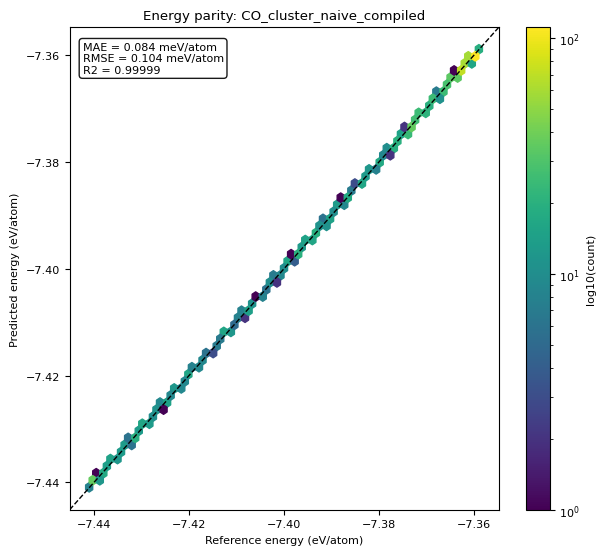

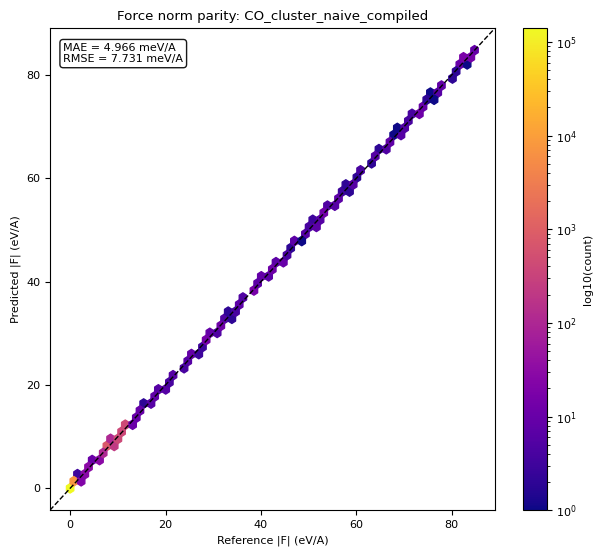

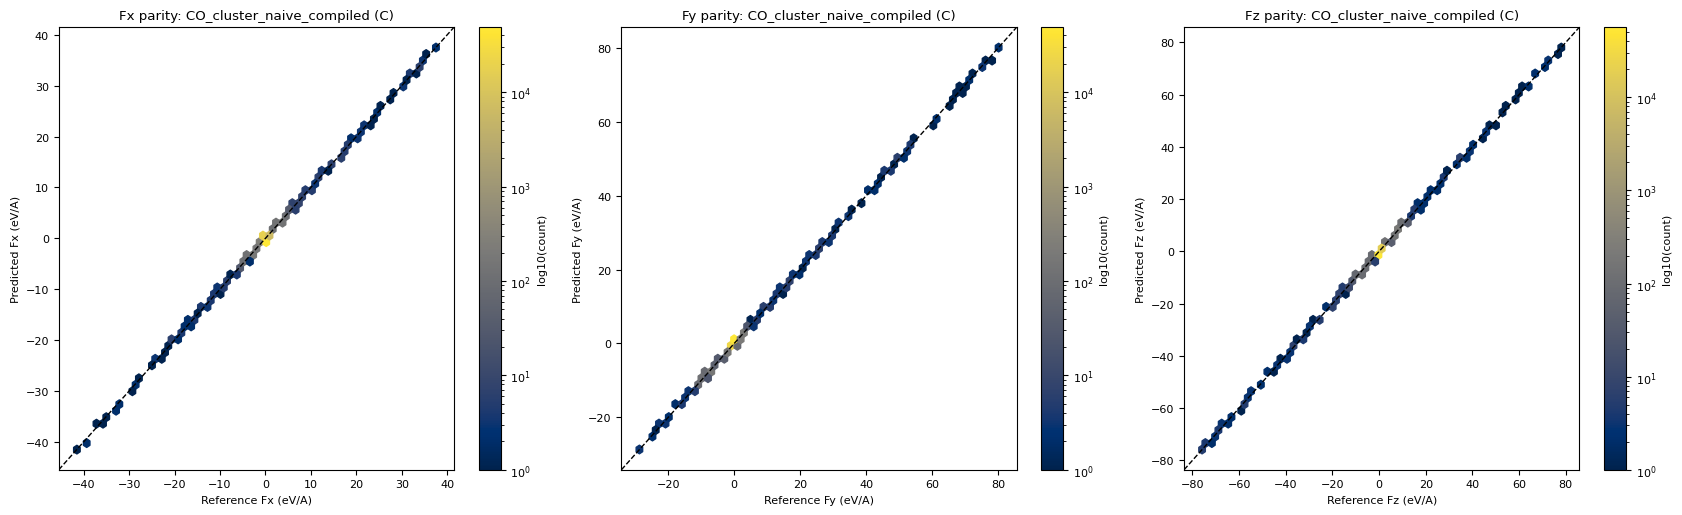

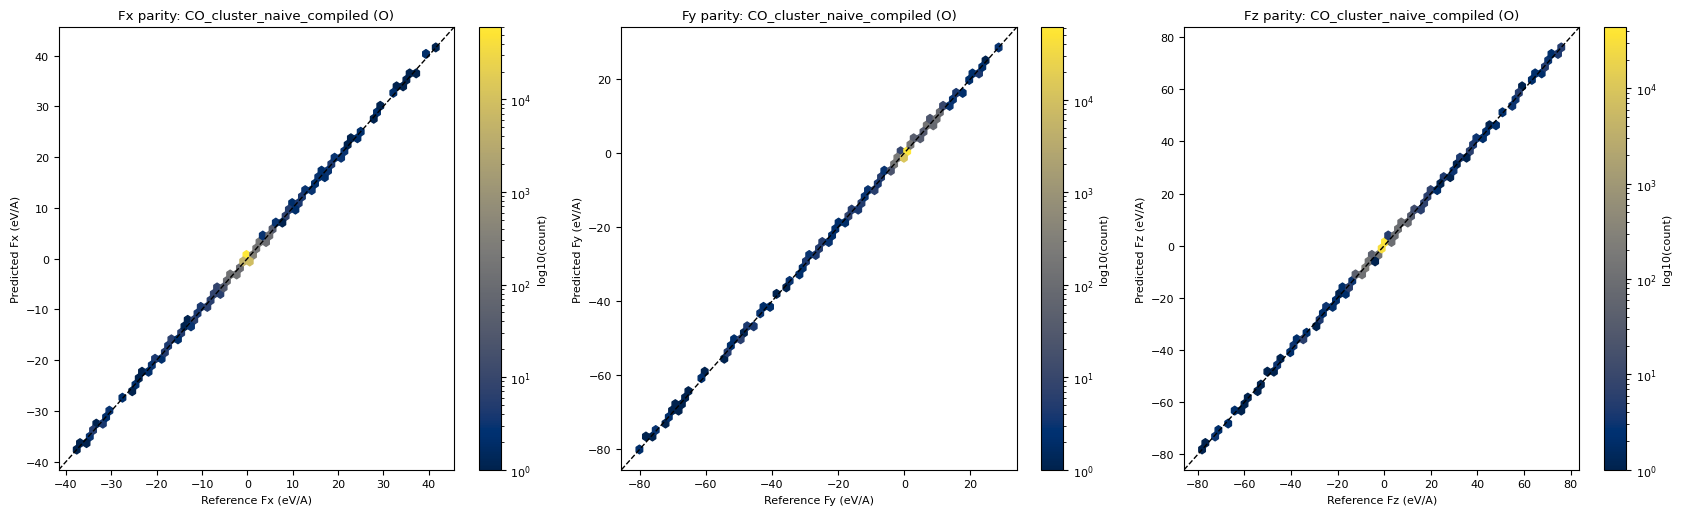

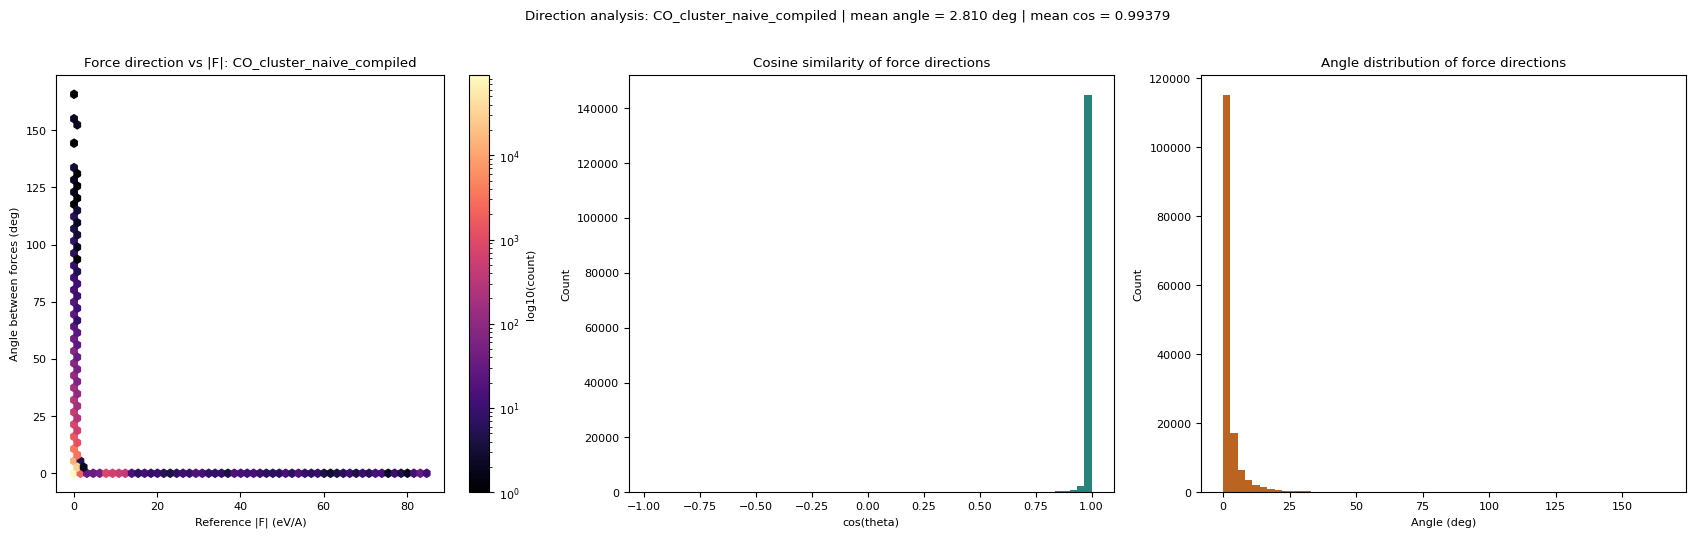

In [7]:
for model_name, result in all_model_results.items():
    model_output_dir = OUTPUT_DIR / model_name
    structure_df = result['structure_df']
    atomic_df = result['atomic_df']
    metrics = result['metrics']
    valid_angle_df = atomic_df.dropna(subset=['cos_theta', 'angle_deg']).copy()

    fig, ax = plt.subplots(figsize=(6.2, 5.6))
    hb = density_parity_plot(
        ax,
        structure_df['energy_ref_eV_per_atom'].to_numpy(),
        structure_df['energy_pred_eV_per_atom'].to_numpy(),
        f'Energy parity: {model_name}',
        'Reference energy (eV/atom)',
        'Predicted energy (eV/atom)',
        cmap='viridis',
    )
    ax.text(
        0.03,
        0.97,
        f"MAE = {metrics['energy_mae_meV_per_atom']:.3f} meV/atom\nRMSE = {metrics['energy_rmse_meV_per_atom']:.3f} meV/atom\nR2 = {metrics['energy_r2']:.5f}",
        transform=ax.transAxes,
        va='top',
        bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9},
    )
    fig.colorbar(hb, ax=ax, label='log10(count)')
    fig.tight_layout()
    fig.savefig(model_output_dir / 'energy_parity.png', dpi=220, bbox_inches='tight')
    display(fig)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.2, 5.6))
    hb = density_parity_plot(
        ax,
        atomic_df['f_norm_ref'].to_numpy(),
        atomic_df['f_norm_pred'].to_numpy(),
        f'Force norm parity: {model_name}',
        'Reference |F| (eV/A)',
        'Predicted |F| (eV/A)',
        cmap='plasma',
    )
    ax.text(
        0.03,
        0.97,
        f"MAE = {metrics['force_norm_mae_meV_A']:.3f} meV/A\nRMSE = {metrics['force_norm_rmse_meV_A']:.3f} meV/A",
        transform=ax.transAxes,
        va='top',
        bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9},
    )
    fig.colorbar(hb, ax=ax, label='log10(count)')
    fig.tight_layout()
    fig.savefig(model_output_dir / 'force_norm_parity.png', dpi=220, bbox_inches='tight')
    display(fig)
    plt.close(fig)

    for symbol in sorted(atomic_df['symbol'].unique()):
        species_df = atomic_df[atomic_df['symbol'] == symbol].copy()
        fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
        component_specs = [
            ('fx_ref', 'fx_pred', 'Fx'),
            ('fy_ref', 'fy_pred', 'Fy'),
            ('fz_ref', 'fz_pred', 'Fz'),
        ]
        for ax, (ref_col, pred_col, label) in zip(axes, component_specs):
            hb = density_parity_plot(
                ax,
                species_df[ref_col].to_numpy(),
                species_df[pred_col].to_numpy(),
                f'{label} parity: {model_name} ({symbol})',
                f'Reference {label} (eV/A)',
                f'Predicted {label} (eV/A)',
                cmap='cividis',
            )
            fig.colorbar(hb, ax=ax, label='log10(count)')
        fig.tight_layout()
        fig.savefig(model_output_dir / f'force_components_{symbol}.png', dpi=220, bbox_inches='tight')
        display(fig)
        plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
    hb0 = axes[0].hexbin(
        valid_angle_df['f_norm_ref'].to_numpy(),
        valid_angle_df['angle_deg'].to_numpy(),
        gridsize=HEXBIN_GRIDSIZE,
        mincnt=1,
        bins='log',
        cmap='magma',
    )
    axes[0].set_xlabel('Reference |F| (eV/A)')
    axes[0].set_ylabel('Angle between forces (deg)')
    axes[0].set_title(f'Force direction vs |F|: {model_name}')
    fig.colorbar(hb0, ax=axes[0], label='log10(count)')

    axes[1].hist(valid_angle_df['cos_theta'].to_numpy(), bins=60, color='#0f766e', alpha=0.9)
    axes[1].set_xlabel('cos(theta)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Cosine similarity of force directions')

    axes[2].hist(valid_angle_df['angle_deg'].to_numpy(), bins=60, color='#b45309', alpha=0.9)
    axes[2].set_xlabel('Angle (deg)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Angle distribution of force directions')

    fig.suptitle(
        f"Direction analysis: {model_name} | mean angle = {metrics['force_direction_mean_angle_deg']:.3f} deg | mean cos = {metrics['force_direction_mean_cosine']:.5f}",
        y=1.02,
    )
    fig.tight_layout()
    fig.savefig(model_output_dir / 'force_direction_analysis.png', dpi=220, bbox_inches='tight')
    display(fig)
    plt.close(fig)

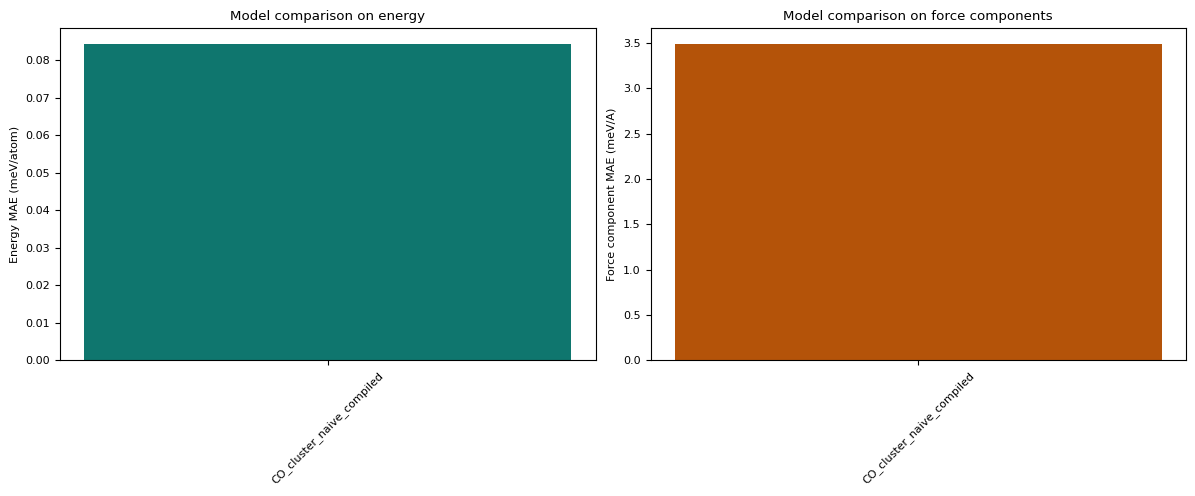

,model,n_files,n_structures,n_atoms_total,energy_mae_meV_per_atom,energy_rmse_meV_per_atom,energy_r2,force_norm_mae_meV_A,force_norm_rmse_meV_A,force_component_mae_meV_A,force_component_rmse_meV_A,force_component_r2,force_direction_mean_cosine,force_direction_mean_angle_deg,force_direction_median_angle_deg
0,CO_cluster_naive_compiled,5.0,1498.0,149800.0,0.084216,0.103888,0.999985,4.966334,7.73115,3.487391,5.545056,0.999991,0.993793,2.810296,1.061977


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(summary_df['model'], summary_df['energy_mae_meV_per_atom'], color='#0f766e')
axes[0].set_ylabel('Energy MAE (meV/atom)')
axes[0].set_title('Model comparison on energy')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(summary_df['model'], summary_df['force_component_mae_meV_A'], color='#b45309')
axes[1].set_ylabel('Force component MAE (meV/A)')
axes[1].set_title('Model comparison on force components')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=220, bbox_inches='tight')
display(fig)
plt.close(fig)

summary_df